In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm
from random import choices, seed  # Import 'choices' and 'seed'

In [3]:
print("Checkpoint: Loading graph from file...")
G1 = nx.read_edgelist(r"/Users/periperi/Desktop/SNA-Project/as-caida/data.txt", nodetype=int)
print("Graph loaded!")

Checkpoint: Loading graph from file...
Graph loaded!


In [4]:
def generate_ba_network(n, m0, m, random_seed=None):
    """
    Generate a scale-free network using the Barabási–Albert model.
    
    Parameters:
        n (int): Total number of nodes in the final network.
        m0 (int): Number of nodes in the initial connected network.
        m (int): Number of edges to attach from a new node to existing nodes.
        random_seed (int, optional): Seed for reproducibility. Defaults to None.
        
    Returns:
        G (networkx.Graph): Generated scale-free network.
    """
    # Set the random seed for reproducibility
    if random_seed is not None:
        seed(random_seed)  # Fix the seed for Python's random module

    # Step 1: Initialize a fully connected graph with m0 nodes
    G = nx.complete_graph(m0)
    
    # Step 2: Add new nodes one by one
    for new_node in tqdm(range(m0, n), desc="Adding nodes"):
        # Calculate degrees of existing nodes
        degrees = [G.degree(node) for node in G.nodes()]
        total_degree = sum(degrees)
        
        # Preferential attachment: Probability proportional to degree
        probabilities = [deg / total_degree for deg in degrees]
        
        # Select m nodes to connect to based on probabilities
        targets = list(range(len(G.nodes())))
        selected_nodes = []
        while len(selected_nodes) < m:
            chosen_node = choices(targets, probabilities)[0]
            if chosen_node not in selected_nodes:
                selected_nodes.append(chosen_node)
        
        # Add edges between the new node and selected nodes
        for target in selected_nodes:
            G.add_edge(new_node, target)
    
    return G

# Parameters for the BA model
total_nodes = 10000  # Final number of nodes
initial_nodes = 100  # Initial number of nodes (m0)
edges_per_new_node = 5  # Number of edges added per new node (m)
fixed_seed = 42  # Fixed random seed for reproducibility

# Generate the scale-free network
scale_free_network = generate_ba_network(total_nodes, initial_nodes, edges_per_new_node, random_seed=fixed_seed)

S = scale_free_network


Adding nodes: 100%|██████████| 9900/9900 [00:19<00:00, 495.83it/s] 


In [5]:
# Check if S is connected
if nx.is_connected(S):
    print("S is connected — the whole graph is the giant component.")
    S_gc = S  # No need to extract anything
else:
    print("S is not connected — extracting the giant component.")
    largest_cc_S = max(nx.connected_components(S), key=len)
    S_gc = S.subgraph(largest_cc_S).copy()

# Print stats about the giant component
print(f"Giant Component of S — Nodes: {S_gc.number_of_nodes()}, Edges: {S_gc.number_of_edges()}")


S is connected — the whole graph is the giant component.
Giant Component of S — Nodes: 10000, Edges: 54450


In [6]:
# Check if G1 is connected
if nx.is_connected(G1):
    print("G1 is connected — the whole graph is the giant component.")
    G1_gc = G1
else:
    print("G1 is not connected — extracting the giant component.")
    largest_cc_G1 = max(nx.connected_components(G1), key=len)
    G1_gc = G1.subgraph(largest_cc_G1).copy()

# Print stats
print(f"Giant Component of G1 — Nodes: {G1_gc.number_of_nodes()}, Edges: {G1_gc.number_of_edges()}")


G1 is connected — the whole graph is the giant component.
Giant Component of G1 — Nodes: 26475, Edges: 53381


In [7]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def analyze_graph(G, name="Graph"):
    print(f"\n--- {name} ---")

    # 1. Number of nodes and edges
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    print(f"Nodes: {num_nodes}")
    print(f"Edges: {num_edges}")

    # 2. Average degree
    avg_degree = sum(dict(G.degree()).values()) / num_nodes
    print(f"Average Degree: {avg_degree:.4f}")

    # 3. Degree distribution
    degrees = [deg for node, deg in G.degree()]
    plt.figure(figsize=(8, 5))
    plt.hist(degrees, bins=100, log=True, color='skyblue', edgecolor='black')
    plt.title(f"Degree Distribution - {name}")
    plt.xlabel("Degree")
    plt.ylabel("Frequency (log scale)")
    plt.grid(True)
    plt.show()

    # 4. Average local clustering coefficient
    clustering_coeff = nx.average_clustering(G)
    print(f"Average Clustering Coefficient (Local): {clustering_coeff:.4f}")

    # 4b. Global clustering coefficient (Transitivity)
    transitivity = nx.transitivity(G)
    print(f"Global Clustering Coefficient (Transitivity): {transitivity:.4f}")

    # 5. Diameter (on the largest connected component)
    if nx.is_connected(G):
        diameter = nx.diameter(G)
        print(f"Diameter: {diameter}")
        avg_path_len = nx.average_shortest_path_length(G)
        print(f"Average Shortest Path Length: {avg_path_len:.4f}")
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        G_lcc = G.subgraph(largest_cc).copy()
        diameter = nx.diameter(G_lcc)
        print(f"Diameter (Largest Connected Component): {diameter}")
        avg_path_len = nx.average_shortest_path_length(G_lcc)
        print(f"Average Shortest Path Length (Largest Connected Component): {avg_path_len:.4f}")



--- Synthetic Network (S) ---
Nodes: 10000
Edges: 54450
Average Degree: 10.8900


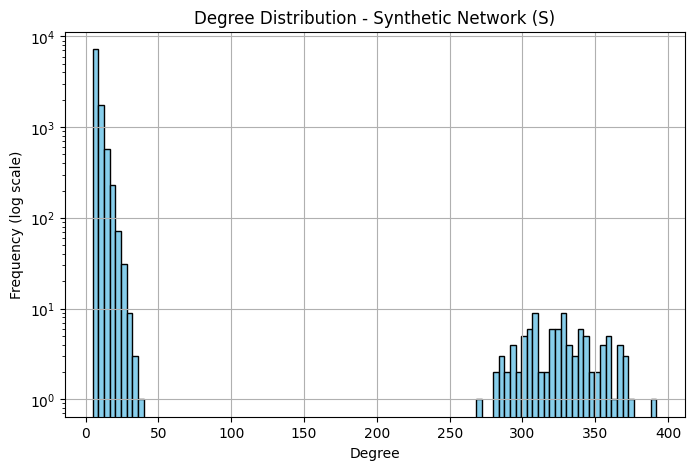

Average Clustering Coefficient (Local): 0.1110
Global Clustering Coefficient (Transitivity): 0.0988
Diameter: 5
Average Shortest Path Length: 3.0225


In [8]:
analyze_graph(S_gc, name="Synthetic Network (S)")


--- CAIDA (G1) ---
Nodes: 26475
Edges: 53381
Average Degree: 4.0326


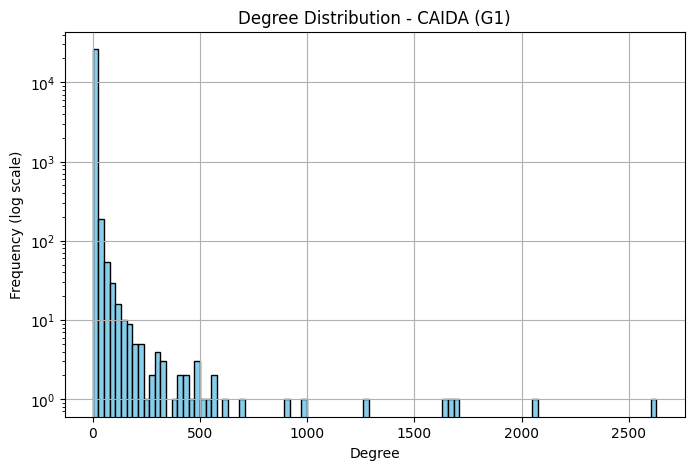

Average Clustering Coefficient (Local): 0.2082
Global Clustering Coefficient (Transitivity): 0.0073
Diameter: 17
Average Shortest Path Length: 3.8756


In [9]:
analyze_graph(G1_gc, name="CAIDA (G1)")


In [10]:
def centrality_measures(G, name="Graph"):
    print(f"\n--- Centrality Measures for {name} ---")

    # Degree Centrality
    deg_centrality = nx.degree_centrality(G)
    avg_deg_cent = sum(deg_centrality.values()) / len(deg_centrality)
    print(f"Average Degree Centrality: {avg_deg_cent:.4f}")

    # Betweenness Centrality
    print("Computing Betweenness Centrality...")
    btw_centrality = nx.betweenness_centrality(G, k=100, seed=42)  # Approximate for performance
    avg_btw_cent = sum(btw_centrality.values()) / len(btw_centrality)
    print(f"Average Betweenness Centrality: {avg_btw_cent:.4f}")

    # Closeness Centrality
    print("Computing Closeness Centrality...")
    closeness_centrality = nx.closeness_centrality(G)
    avg_close_cent = sum(closeness_centrality.values()) / len(closeness_centrality)
    print(f"Average Closeness Centrality: {avg_close_cent:.4f}")

    # Eigenvector Centrality
    try:
        print("Computing Eigenvector Centrality...")
        eigen_centrality = nx.eigenvector_centrality(G, max_iter=1000)
        avg_eigen_cent = sum(eigen_centrality.values()) / len(eigen_centrality)
        print(f"Average Eigenvector Centrality: {avg_eigen_cent:.4f}")
    except nx.NetworkXException as e:
        print(f"Eigenvector Centrality couldn't be computed: {e}")

    # PageRank (Optional)
    try:
        print("Computing PageRank...")
        pagerank = nx.pagerank(G, alpha=0.85)
        avg_pagerank = sum(pagerank.values()) / len(pagerank)
        print(f"Average PageRank: {avg_pagerank:.4f}")
    except Exception as e:
        print(f"PageRank couldn't be computed: {e}")

In [11]:
centrality_measures(S_gc, name="Synthetic Network (S)")
centrality_measures(G1_gc, name="CAIDA (G1)")



--- Centrality Measures for Synthetic Network (S) ---
Average Degree Centrality: 0.0011
Computing Betweenness Centrality...
Average Betweenness Centrality: 0.0002
Computing Closeness Centrality...
Average Closeness Centrality: 0.3325
Computing Eigenvector Centrality...
Average Eigenvector Centrality: 0.0032
Computing PageRank...
Average PageRank: 0.0001

--- Centrality Measures for CAIDA (G1) ---
Average Degree Centrality: 0.0002
Computing Betweenness Centrality...
Average Betweenness Centrality: 0.0001
Computing Closeness Centrality...
Average Closeness Centrality: 0.2630
Computing Eigenvector Centrality...
Average Eigenvector Centrality: 0.0024
Computing PageRank...
Average PageRank: 0.0000


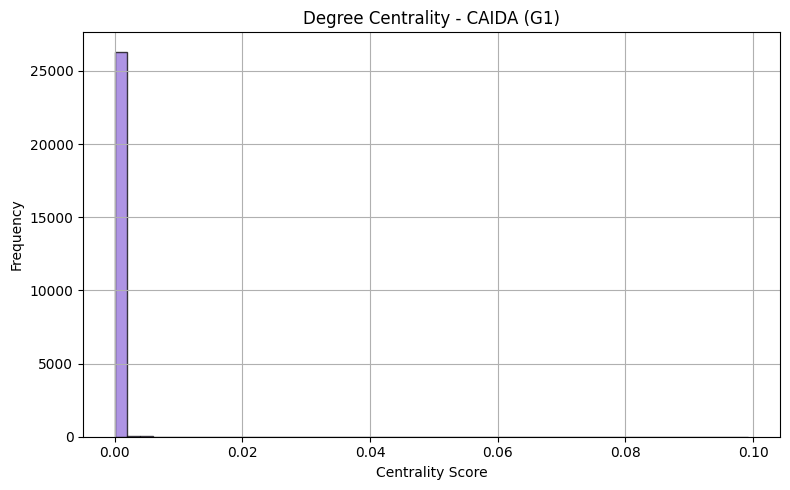

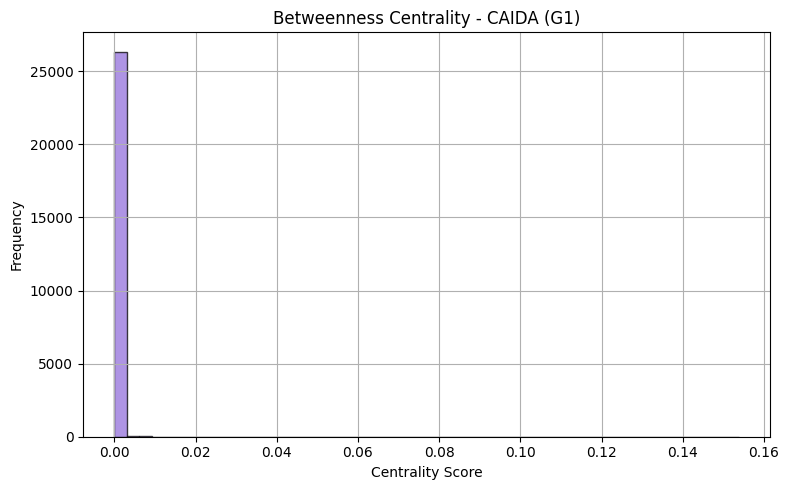

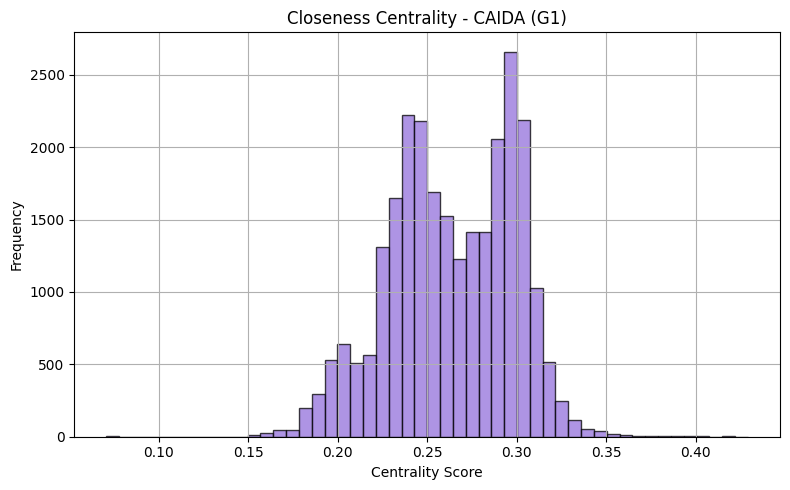

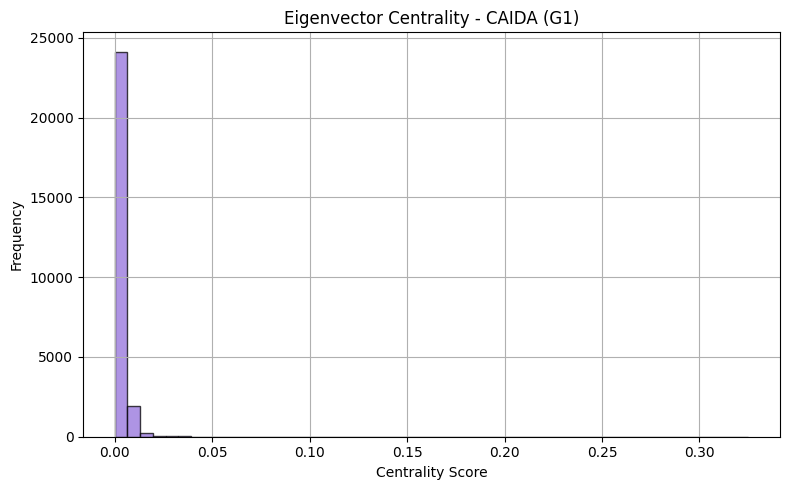

In [12]:
import matplotlib.pyplot as plt

def plot_centrality_distribution(centrality_dict, title):
    plt.figure(figsize=(8, 5))
    values = list(centrality_dict.values())
    plt.hist(values, bins=50, color='mediumpurple', edgecolor='black', alpha=0.75)
    plt.title(f'{title} - CAIDA (G1)')
    plt.xlabel('Centrality Score')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Calculate centralities again (if not already done)
deg_cent_g1 = nx.degree_centrality(G1_gc)
bet_cent_g1 = nx.betweenness_centrality(G1_gc)
close_cent_g1 = nx.closeness_centrality(G1_gc)
eig_cent_g1 = nx.eigenvector_centrality(G1_gc, max_iter=1000)

# Plot each
plot_centrality_distribution(deg_cent_g1, "Degree Centrality")
plot_centrality_distribution(bet_cent_g1, "Betweenness Centrality")
plot_centrality_distribution(close_cent_g1, "Closeness Centrality")
plot_centrality_distribution(eig_cent_g1, "Eigenvector Centrality")


import matplotlib.pyplot as plt

def plot_all_centralities(g, name="CAIDA (G1)"):
    centralities = {
        "Degree": nx.degree_centrality(g),
        "Betweenness": nx.betweenness_centrality(g),
        "Closeness": nx.closeness_centrality(g),
        "Eigenvector": nx.eigenvector_centrality(g, max_iter=1000)
    }

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.ravel()

    for i, (title, values) in enumerate(centralities.items()):
        axs[i].hist(list(values.values()), bins=50, color='darkorange', edgecolor='black', alpha=0.75)
        axs[i].set_title(f'{title} Centrality')
        axs[i].set_xlabel('Score')
        axs[i].set_ylabel('Frequency')
        axs[i].grid(True)

    plt.suptitle(f'Centrality Distributions - {name}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_all_centralities(G1_gc, name="CAIDA (G1)")
